In [1]:
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq_nex, AmpInterpKerrEccEq
import numpy as np
import matplotlib.pyplot as plt
from few.utils.mappings.kerrecceq import (kerrecceq_backward_map, kerrecceq_backward_map_nex, z_of_a,apex_of_uwyz_nex,
                                           y_of_x, z_of_a_nex, DELTAPMIN_REGIONC, kerrecceq_forward_map, kerrecceq_forward_map_nex, DELTAPMIN_REGIONC_amp)
from few.utils.geodesic import get_separatrix
import tqdm
import h5py

from few import get_file_manager
#kerr_amp_spline_nex = AmpInterpKerrEccEq_nex()
#kerr_amp_spline = AmpInterpKerrEccEq()

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 16,
})


In [3]:
kerr_amp_spline_nex = AmpInterpKerrEccEq_nex()
kerr_amp_spline = AmpInterpKerrEccEq()

In [3]:
u,w,y,z = np.linspace(0,1,17),np.linspace(0,1,17),np.linspace(0,1,17),np.linspace(0,1,17)
a,p,e,x = apex_of_uwyz_nex(u,w,y,z,DELTAPMIN_REGIONC_amp)


aa=0.99

P,E = np.meshgrid(p,e)
A = np.ones_like(P)*aa
X = np.ones_like(P)

PLSO = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PLSO = PLSO.reshape(np.shape(P))
P = np.where(P>PLSO+np.ones_like(PLSO)*DELTAPMIN_REGIONC_amp,P,np.nan)

Z = kerr_amp_spline_nex.get_amplitudes(A.flatten(),P.flatten(),E.flatten(),X.flatten())
Z = np.reshape(Z,(17,17,6791))
Z = np.sum(Z,axis=2)

np.shape(Z)
fig,ax = plt.subplots(1,1)
cf1 = ax.scatter(np.log10(np.abs(P-PLSO)), E, c = np.imag(Z), cmap="viridis")
ax.set_xlim(-2,2)
#cb1 = ax.colorbar(cf1, ax=ax,pad = 0.01)

NameError: name 'kerr_amp_spline_nex' is not defined

In [4]:
for a in a:
    print(round(a,15))

0.99
0.997628629573051
0.999437660229819
0.99986664840991
0.999968377398287
0.999992501109748
0.999998221735342
0.999999578307578
0.999999900001106
0.999999976286558
0.999999994376664
0.999999998666499
0.999999999683778
0.999999999925012
0.999999999982218
0.999999999995783
0.999999999999


/tmp/ipykernel_218093/2593918823.py:10: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(p-get_separatrix(aa,ee,xx)) , np.real(np.sum( kerr_amp_spline_nex.get_amplitudes(aa,p,ee,xx), axis=1 )), "-")


(-2.0, 1.0)

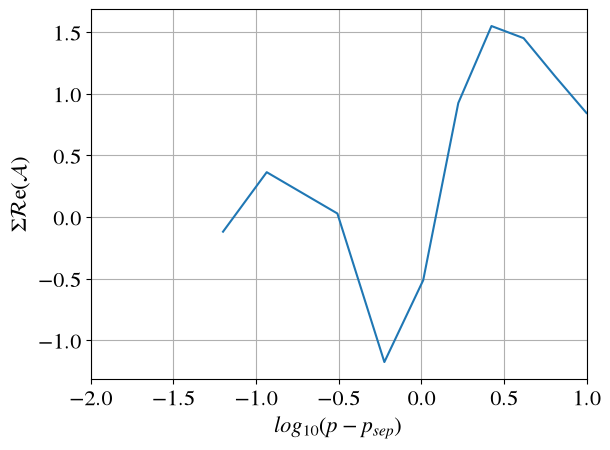

In [68]:
u,w,y,z = np.linspace(0,1,17),np.linspace(0,1,17),np.linspace(0,1,17),np.linspace(0,1,17)
a,p,e,x = apex_of_uwyz_nex(u,w,y,z,DELTAPMIN_REGIONC_amp)


aaa = 1-1e-7
eee=0.4

aa,ee,xx = np.ones_like(p)*aaa,np.ones_like(p)*eee,np.ones_like(p)
p=np.sort(p)
plt.plot(np.log10(p-get_separatrix(aa,ee,xx)) , np.real(np.sum( kerr_amp_spline_nex.get_amplitudes(aa,p,ee,xx), axis=1 )), "-")
plt.grid()
plt.xlabel(r"$log_{10}(p-p_{sep})$")
plt.ylabel(r"$\mathcal{\Sigma Re(A)}$")
plt.xlim(-2,1)

In [71]:
p

array([ 1.17138356,  1.18420832,  1.19680961,  1.22450815,  1.28041952,
        1.28933278,  1.38314479,  1.46449794,  1.5175417 ,  1.71258991,
        2.00019061,  2.42992376,  3.07834747,  4.0634524 ,  5.56698085,
        7.86882396, 11.4000037 ])

In [74]:
p[0] -get_separatrix(0.999, 0,1)


np.float64(-0.010381048097500623)

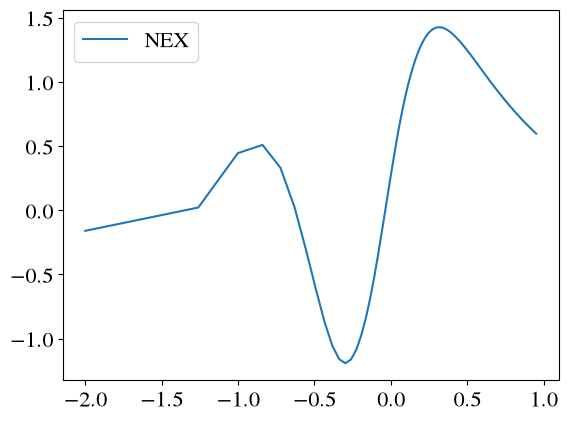

In [79]:
a, e, x = 0.99999999,0.05,1
plso = get_separatrix(a,e,x)

n=200
a,p,e,x = np.ones(n)*a , np.linspace(plso+DELTAPMIN_REGIONC_amp,10,n), np.ones(n)*e, np.ones(n)*x


nex_amps1 = kerr_amp_spline_nex.get_amplitudes(a,p,e,x)

nex=[]

for i,pp in enumerate(p):

    amp = np.sum(nex_amps1[i,:])
    nex.append(amp)

plt.plot(np.log10(p-plso),np.real(nex),"-",label = "NEX")

plt.legend()

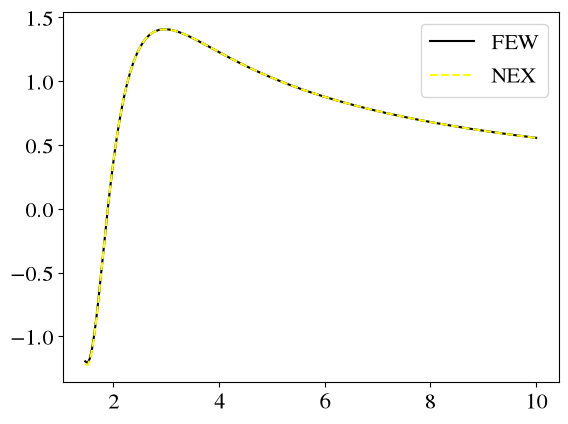

In [ ]:
a, e, x = 0.999,0.004,1
plso = get_separatrix(a,e,x)
n=200
a,p,e,x = np.ones(n)*a , np.linspace(plso+DELTAPMIN_REGIONC_amp,10,n), np.ones(n)*e, np.ones(n)*x

nex_amps = kerr_amp_spline_nex.get_amplitudes(a,p,e,x)
few_amps = kerr_amp_spline.get_amplitudes(a,p,e,x)


nex=[]
few=[]

for i,pp in enumerate(p):


    amp = np.sum(nex_amps[i,:])
    amp_few = np.sum(few_amps[i,:])

    nex.append(amp)
    few.append(amp_few)


plt.plot(p,np.real(few),label = "FEW",color = "black")
plt.plot(p,np.real(nex),"--",label = "NEX",color="yellow")
plt.legend()


In [78]:
a = 0.99
p = 3.0
e = 0.1
xI = 1.0
specific_modes = [(2,2,0,0)]
specific_amplitudes = kerr_amp_spline(a, p, e, xI, specific_modes=specific_modes)
specific_amplitudes_nex = kerr_amp_spline_nex(a, p, e, xI, specific_modes=specific_modes)
specific_amplitudes_nex, specific_amplitudes



({(2, 2, 0, 0): array([1.24248651+0.2036261j])},
 {(2, 2, 0, 0): array([1.21249589-0.03951598j])})

In [8]:
a = 0.99
p = 3.0
e = 0.1
xI = 1.0
specific_modes = [(3,2,0,0)]
specific_amplitudes = kerr_amp_spline(a, p, e, xI, specific_modes=specific_modes)
specific_amplitudes_nex = kerr_amp_spline_nex(a, p, e, xI, specific_modes=specific_modes)
specific_amplitudes_nex, specific_amplitudes


({(3, 2, 0, 0): array([0.10001979-0.0237148j])},
 {(3, 2, 0, 0): array([0.09995937-0.02376176j])})

In [6]:
kerr_amp_spline_nex(a, p, e, xI, specific_modes=specific_modes)

{(14, 2, 0, 0): array([4.50176824e-05-5.61702248e-05j])}

In [119]:

# A rectilinear grid
uv = np.linspace(1e-5, 1 - 1e-5, 101)
wv = np.linspace(1e-5, 1 - 1e-5, 101)

a = 0.99
z = z_of_a(a)
z_nex = z_of_a_nex(a)
y = y_of_x(1)

# For a given rectilinear grid, compute the associated (a,p,e,x) grid
u_grid, w_grid = np.asarray(np.meshgrid(uv, wv, indexing="ij")).reshape(2, -1)

a_grid, p_grid, e_grid, xI_grid = kerrecceq_backward_map(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z, kind="amplitude"
)

a_grid_nex, p_grid_nex, e_grid_nex, xI_grid_nex = kerrecceq_backward_map_nex(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z_nex, kind="amplitude"
)

print("Total trajectory points:", w_grid.shape[0])

Total trajectory points: 10201


In [120]:
teuk_all_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid).reshape(
    uv.size, wv.size, -1
)

teuk_all_amps_nex = kerr_amp_spline_nex(a, p_grid_nex, e_grid_nex, xI_grid_nex).reshape(
    uv.size, wv.size, -1
)

# Specific mode amplitudes for the given (a,p,e,x) data points.
specific_modes = [(2, 2, 0, 0)]

teuk_specific_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid, specific_modes=specific_modes)
teuk_specific_amps_nex = kerr_amp_spline_nex(a, p_grid_nex, e_grid_nex, xI_grid_nex, specific_modes=specific_modes)

# We can find the index to these modes to check
inds = np.array([kerr_amp_spline.special_index_map[lmn] for lmn in specific_modes])
print("Indices of interest:", inds)

# Making sure they are the same
print(
    np.allclose(
        teuk_specific_amps[(2, 2, 0, 0)].reshape(uv.size, wv.size),
        teuk_all_amps[:, :, inds[0]],
    )
)

Indices of interest: [1165]
True


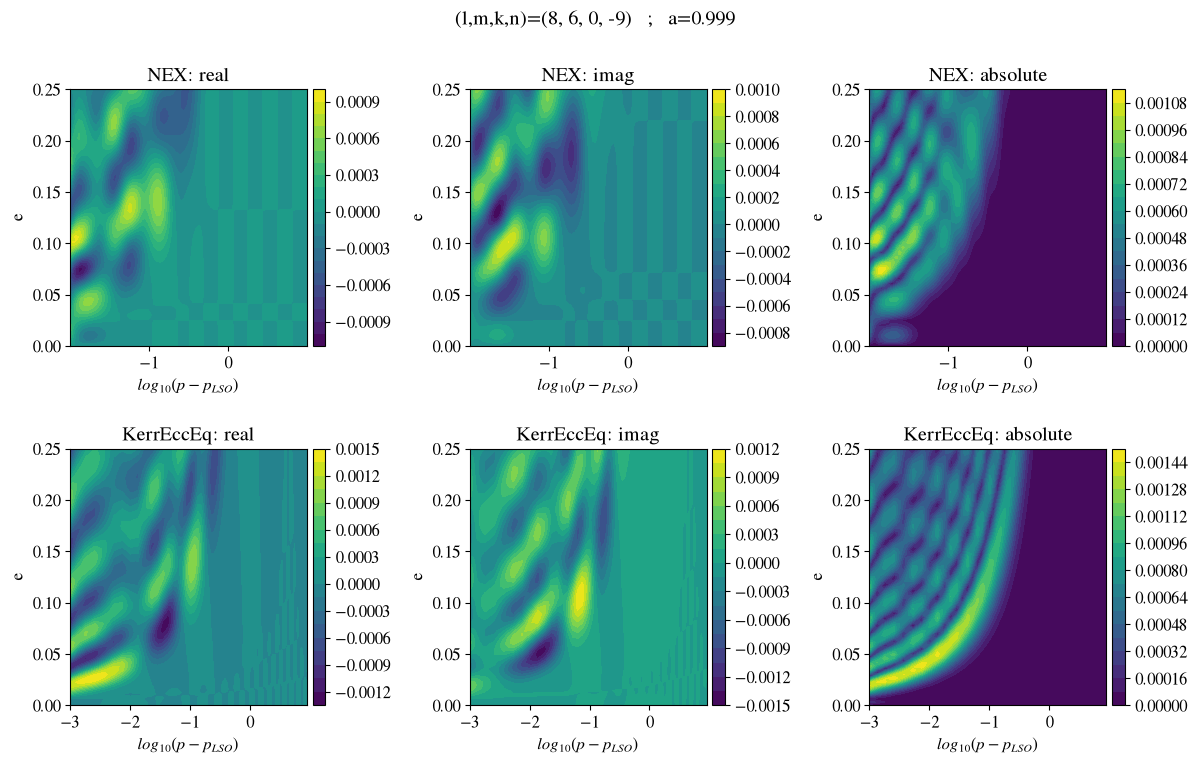

In [5]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
})
l,m,n =8,6,-9
mode = (l,m,0,n)

n1=80
lvls = 20

funcs = [np.real, np.imag, np.abs]

uv = np.linspace(1e-5, 1 - 1e-5, n1)
wv = np.linspace(1e-5, 1 - 1e-5, n1)

a = 0.999
z = z_of_a(a)
z_nex = z_of_a_nex(a)
y = y_of_x(1)

u_grid, w_grid = np.asarray(np.meshgrid(uv, wv, indexing="ij")).reshape(2, -1)

a_grid, p_grid, e_grid, xI_grid = kerrecceq_backward_map(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z, kind="amplitude"
)
plso = get_separatrix(a_grid,e_grid, xI_grid) 

a_grid_nex, p_grid_nex, e_grid_nex, xI_grid_nex = kerrecceq_backward_map_nex(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z_nex, kind="amplitude"
)
plso_nex = get_separatrix(a_grid_nex,e_grid_nex, xI_grid_nex) 

teuk_all_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid).reshape(
    n1, n1, -1
)

teuk_all_amps_nex = kerr_amp_spline_nex(a, p_grid_nex, e_grid_nex, xI_grid_nex).reshape(
    n1, n1, -1
)

fig , axs =plt.subplots(2, 3, figsize=(14, 8))


for i in range(len(funcs)):

    Nex_Z = funcs[i](teuk_all_amps_nex[:, :, kerr_amp_spline_nex.special_index_map[mode]])
    Few_Z = funcs[i](teuk_all_amps[:, :, kerr_amp_spline.special_index_map[mode]])


    cf0 = axs[0, i].contourf(
        np.log10(p_grid_nex.reshape(n1, n1)-plso_nex.reshape(n1,n1)),
        e_grid_nex.reshape(n1, n1),
        Nex_Z,levels = lvls
    )
    cb0 = fig.colorbar(cf0, ax=axs[0, i],pad = 0.02)

    axs[0, i].set_title(f"NEX: {funcs[i].__name__}")
    axs[0, i].set_xlabel(r"$log_{10}(p-p_{LSO})$")
    axs[0, i].set_ylabel("e")


    cf1 = axs[1, i].contourf(
        np.log10(p_grid.reshape(n1, n1)-plso.reshape(n1,n1)),
        e_grid.reshape(n1, n1),
        Few_Z,levels = lvls
    )
    cb1 = fig.colorbar(cf1, ax=axs[1, i],pad = 0.02)

    axs[1, i].set_title(f"KerrEccEq: {funcs[i].__name__}")
    axs[1, i].set_xlabel(r"$log_{10}(p-p_{LSO})$")
    axs[1, i].set_ylabel("e")

    axs[1, i].set_ylim(0, 0.25)
    axs[0, i].set_ylim(0, 0.25)
    #axs[1, i].set_xlim(-1.625, 1)
    #axs[0, i].set_xlim(-1.625, 1)


plt.suptitle(rf"(l,m,k,n)={mode}   ;   a={a}")

fig.subplots_adjust(
    wspace=0.4,  # horizontal space between subplots
    hspace=0.4   # vertical space between subplots
)


#axs[1,2].set_xlim(1,3)
#axs[0,2].set_xlim(1,3)

#fig.savefig(f"FEW_NEX_side-by-side_a={a}_A_{mode[0]}_{mode[1]}_{mode[2]}_{mode[3]}.png", dpi=300, bbox_inches="tight")


### Compare Amplitudes like eq. 14 in FEW [paper](https://arxiv.org/pdf/2506.09470)

In [2]:
nex_amp = AmpInterpKerrEccEq_nex()
few_amp = AmpInterpKerrEccEq()

In [4]:
import time

t1=time.time()
nex_amp.get_amplitudes(np.array([0.99]), np.array([4]), np.array([0.2]),np.array([1]))


t2= time.time()

nex_amp(np.array([0.999]), np.array([6]), np.array([0.2]),np.array([1]))

t3 = time.time()

print(f"Time taken1 = {t2-t1},,Time taken2 = {t3-t2}")

Time taken1 = 0.027622461318969727,,Time taken2 = 0.015626192092895508


In [3]:
#A function to compute the amplitudes on a grid
def snap_MM(a,p,e,x):

    if np.isscalar(a) and np.isscalar(p) and np.isscalar(e) and np.isscalar(x):
        a,p,e,x = np.array([a]), np.array([p]), np.array([e]), np.array([x])

    amp_list = []
    amp_nex_list = []

    sa,sp,se, sx = np.size(a),np.size(p),np.size(e),np.size(x)
    a,p,e,x = a.flatten(), p.flatten(), e.flatten(), x.flatten()

    split_len = int(len(a)/500)

 
    print(f"Number of iterations to complete = {round(split_len)}")

    a_split = np.array_split(a, split_len)
    p_split = np.array_split(p, split_len)
    e_split = np.array_split(e, split_len)
    x_split = np.array_split(x, split_len)

    for aa,pp,ee,xx in tqdm.tqdm(zip(a_split,p_split,e_split,x_split)):

        
        amps = few_amp.get_amplitudes(aa, pp, ee, xx)
        amps_nex = nex_amp.get_amplitudes(aa, pp, ee, xx)

        amp = np.nansum(amps,axis=1)
        amp_nex = np.nansum(amps_nex,axis=1)

        amp_list.append(amp)
        amp_nex_list.append(amp_nex)

        del amps, amps_nex, amp, amp_nex

    amps = np.asarray(amp_list).reshape(sa,-1)
    amps_nex = np.asarray(amp_nex_list).reshape(sa,-1)

    return amps, amps_nex

def Amp_nex_summed(a,p,e,x):

    if np.isscalar(a) and np.isscalar(p) and np.isscalar(e) and np.isscalar(x):
        a,p,e,x = np.array([a]), np.array([p]), np.array([e]), np.array([x])

    amp_nex_list = []

    sa,sp,se, sx = np.size(a),np.size(p),np.size(e),np.size(x)
    a,p,e,x = a.flatten(), p.flatten(), e.flatten(), x.flatten()

    split_len = int(len(a)/500)

 
    print(f"Number of iterations to complete = {round(split_len)}")

    a_split = np.array_split(a, split_len)
    p_split = np.array_split(p, split_len)
    e_split = np.array_split(e, split_len)
    x_split = np.array_split(x, split_len)

    for aa,pp,ee,xx in tqdm.tqdm(zip(a_split,p_split,e_split,x_split)):

        
        amps_nex = nex_amp.get_amplitudes(aa, pp, ee, xx)
        amp_nex = np.nansum(amps_nex,axis=1)
        amp_nex_list.append(amp_nex)

        del  amps_nex, amp_nex


    amps_nex = np.asarray(amp_nex_list).reshape(sa,-1)

    return amps_nex


In [30]:
a,p,e,x = np.linspace(0.999, 0.999, 1000), np.linspace(3, 10, 1000), np.linspace(0, 0.4, 1000), np.ones_like(np.linspace(3, 10, 1000))

amps,amps_nex = snap_MM(a, p, e, x)

Number of iterations ot complete = 10


10it [00:04,  2.13it/s]


In [7]:
sum(few_amp.get_amplitudes(np.array([0.999]), np.array([3]), np.array([0]), np.array([1]))[0,:])

np.complex128(1.4029971584634364+0.3918890761236422j)

In [11]:
x=1
n=2
a=1-10**(-n)
n1,n2 =500,1000

e = np.linspace(0, 0.25, n1)
p= np.linspace(1,10,n2)

P,E = np.meshgrid(p, e)
A= np.ones_like(P)*a
X= np.ones_like(P)

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)


P = np.where(P > PSEP+np.ones_like(PSEP)*(DELTAPMIN_REGIONC_amp), P, np.nan)


Z_few, Z_nex = snap_MM(A.flatten(),P.flatten(),E.flatten(),X.flatten())

Z_few = Z_few.reshape(n1,n2)
Z_nex = Z_nex.reshape(n1,n2)




    

Number of iterations to complete = 1000


419it [22:16,  3.19s/it]


KeyboardInterrupt: 

In [21]:
#Z_nex_n2 = Z_nex
#Z_few_n2 = Z_few save n=2 data

In [9]:
rel_diff_real = np.abs((np.real(Z_nex - Z_few))/(np.real(Z_nex)))
rel_diff_imag = np.abs((np.imag(Z_nex - Z_few))/(np.imag(Z_nex)))
rel_diff_abs= np.abs((np.abs(Z_nex) - np.abs(Z_few))/(np.abs(Z_nex)))



/tmp/ipykernel_37289/2707064884.py:1: RuntimeWarning: invalid value encountered in divide
  rel_diff_real = np.abs((np.real(Z_nex - Z_few))/(np.real(Z_nex)))
/tmp/ipykernel_37289/2707064884.py:2: RuntimeWarning: invalid value encountered in divide
  rel_diff_imag = np.abs((np.imag(Z_nex - Z_few))/(np.imag(Z_nex)))
/tmp/ipykernel_37289/2707064884.py:3: RuntimeWarning: invalid value encountered in divide
  rel_diff_abs= np.abs((np.abs(Z_nex) - np.abs(Z_few))/(np.abs(Z_nex)))


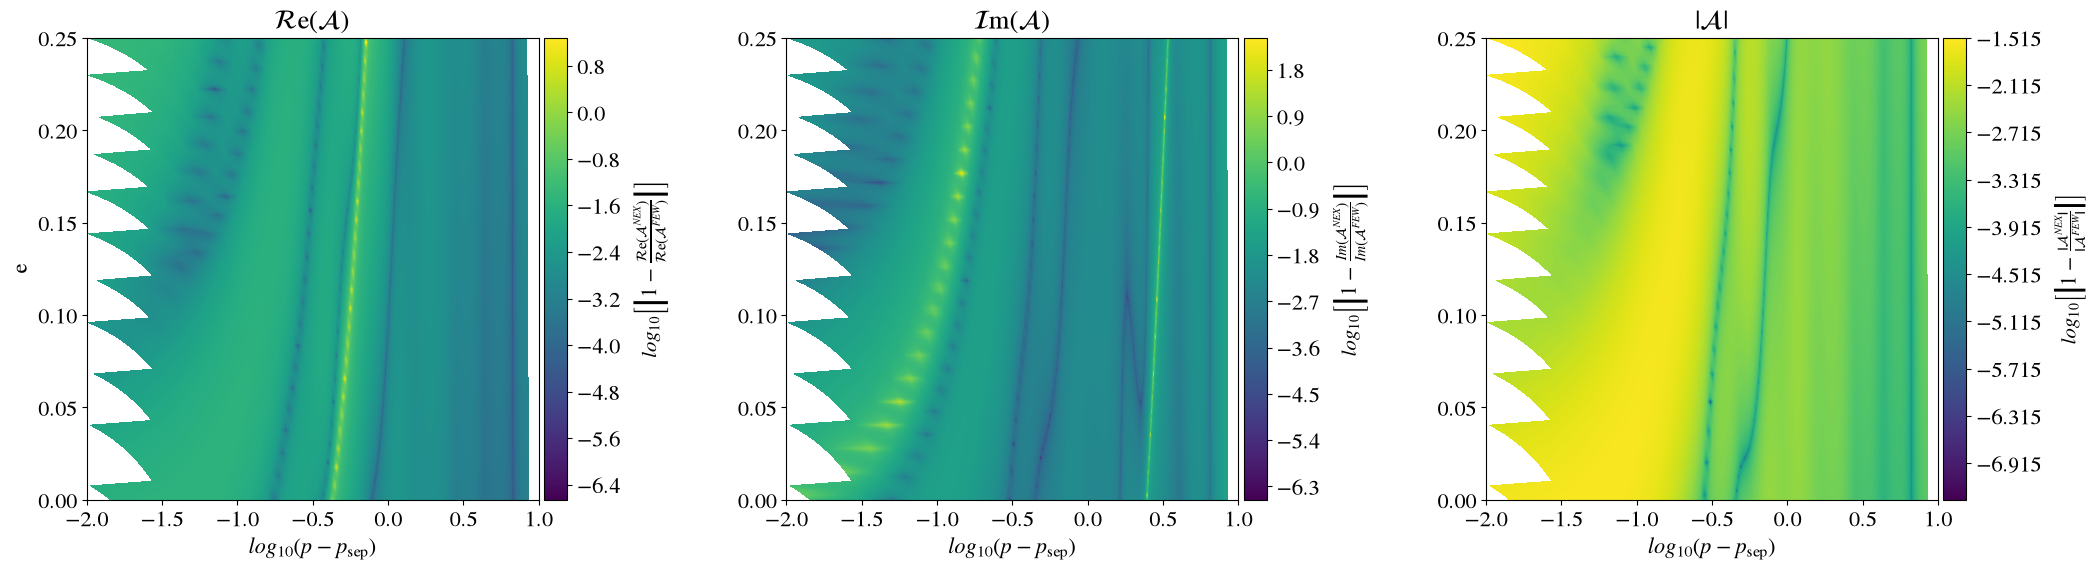

In [10]:
fig, ax = plt.subplots(1,3,figsize = (25,6))
lvls=500

cf1 = ax[0].contourf(np.log10(np.abs(P-PSEP)), E, np.log10(rel_diff_real), levels=lvls, cmap="viridis")
cb1 = fig.colorbar(cf1, ax=ax[0],pad = 0.01)
cf2 = ax[1].contourf(np.log10(np.abs(P-PSEP)), E, np.log10(rel_diff_imag), levels=lvls, cmap="viridis")
cb2 = fig.colorbar(cf2, ax=ax[1] ,pad = 0.01)
cf3 = ax[2].contourf(np.log10(np.abs(P-PSEP)), E, np.log10(rel_diff_abs), levels=lvls, cmap="viridis")
cb3 = fig.colorbar(cf3, ax=ax[2] ,pad = 0.01)


cb1.set_label(r"$log_{10} \left[ \left|1-\frac{ \mathcal{Re} (\mathcal{A}^{NEX}) }{ \mathcal{Re} (\mathcal{A}^{FEW}) }\right| \right]$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )

cb2.set_label(r"$log_{10}\left[ \left|1-\frac{Im\left(\mathcal{A}^{NEX}\right)}{Im(\mathcal{A}^{FEW})}\right| \right]$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )


cb3.set_label(r"$log_{10}\left[ \left|1-\frac{|\mathcal{A}^{NEX}|}{|\mathcal{A}^{FEW}|}\right| \right]$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )



ax[0].set_xlim(-2,1)
ax[1].set_xlim(-2,1)
ax[2].set_xlim(-2,1)

ax[0].set_ylim(0.,0.25)
ax[1].set_ylim(0,0.25)
ax[2].set_ylim(0,0.25)

ax[0].set_title(r"$\mathcal{Re(A)}$")
ax[1].set_title(r"$\mathcal{Im(A)}$")
ax[2].set_title(r"$\mathcal{|A|}$")

ax[0].set_ylabel("e")

ax[1].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
ax[0].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
ax[2].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
#ax[1].set_ylabel("e")


plt.subplots_adjust(
    wspace=0.3,  
    hspace=0.6
)


#plt.suptitle(rf"a=$1-10^{{-{n}}}$, Relative differences in amplitudes")
plt.show()
#fig.savefig(f"Rel_diff_amps_n={n}_v2.png", dpi=300, bbox_inches="tight")


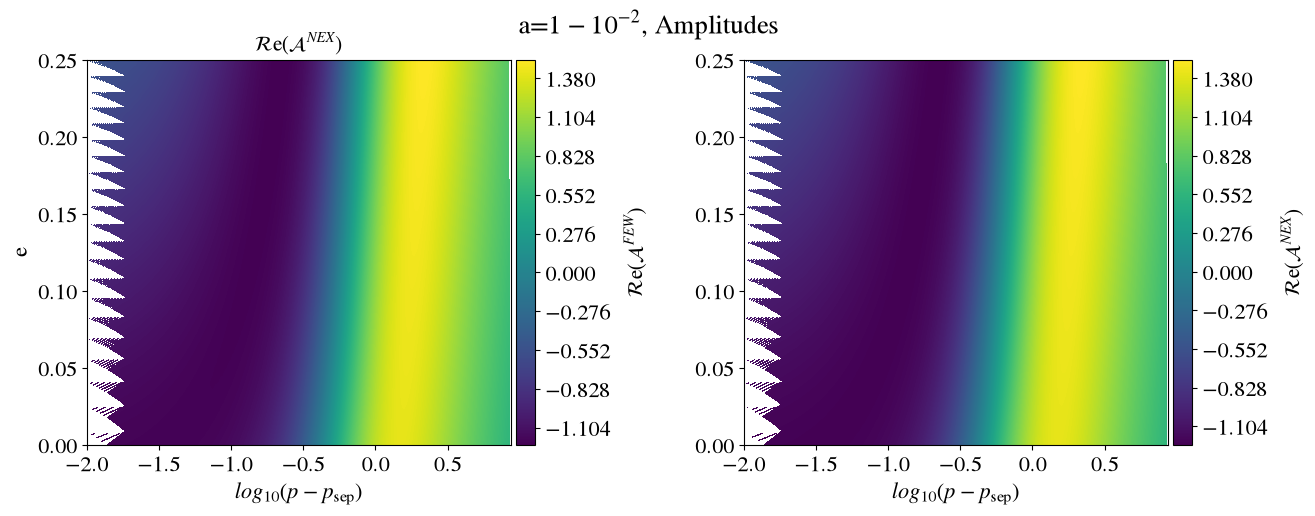

In [65]:
fig, ax = plt.subplots(1,2,figsize = (15,5))
lvs = 1000

cf1 = ax[0].contourf(np.log10(np.abs(P-PSEP)), E, np.real(Z_few), levels=lvs, cmap="viridis")
cb1 = fig.colorbar(cf1, ax=ax[0],pad = 0.01)
cf2 = ax[1].contourf(np.log10(np.abs(P-PSEP)), E, np.real(Z_nex), levels=lvs, cmap="viridis")
cb2 = fig.colorbar(cf2, ax=ax[1] ,pad = 0.01)

cb1.set_label(r"$\mathcal{Re}(\mathcal{A}^{FEW})$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )

cb2.set_label(r"$\mathcal{Re}\left(\mathcal{A}^{NEX}\right)$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )
ax[0].set_title(r"$\mathcal{Re}\left(\mathcal{A}^{NEX}\right)$" ,
            fontname ="STIXGeneral",fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )


ax[0].set_xlim(-2,0.94)
ax[1].set_xlim(-2,0.94)

ax[0].set_ylim(0.,0.25)
ax[1].set_ylim(0,0.25)

ax[0].set_ylabel("e")

ax[1].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
ax[0].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
#ax[1].set_ylabel("e")


plt.subplots_adjust(
    wspace=0.3,  
    hspace=0.15
)


plt.suptitle(rf"a=$1-10^{{-{n}}}$, Amplitudes")
plt.show()
#fig.savefig(f"Amps_n={n}_ABS.png", dpi=300, bbox_inches="tight")

In [18]:
np.array_split(a,3)[0]

array([0.999, 0.999, 0.999, 0.999])

In [129]:
10**(-0.3)

0.5011872336272722

In [2]:
nex_amp = AmpInterpKerrEccEq_nex()

In [51]:
x=1
n=8
a=1-10**(-n)
n1,n2 =200,200

e = np.linspace(0.1, 0.3, n1)
p= np.linspace(1,2,n2)

P,E = np.meshgrid(p, e)
A= np.ones_like(P)*a
X= np.ones_like(P)

PSEP = get_separatrix(A.flatten(),E.flatten(),X.flatten())
PSEP = PSEP.reshape(n1,n2)


P = np.where(P > PSEP+np.ones_like(PSEP)*(DELTAPMIN_REGIONC_amp), P, np.nan)


Z_nex= Amp_nex_summed(A,P,E,X)
Z_nex = Z_nex.reshape(n1,n2)

Number of iterations to complete = 80


80it [01:03,  1.25it/s]


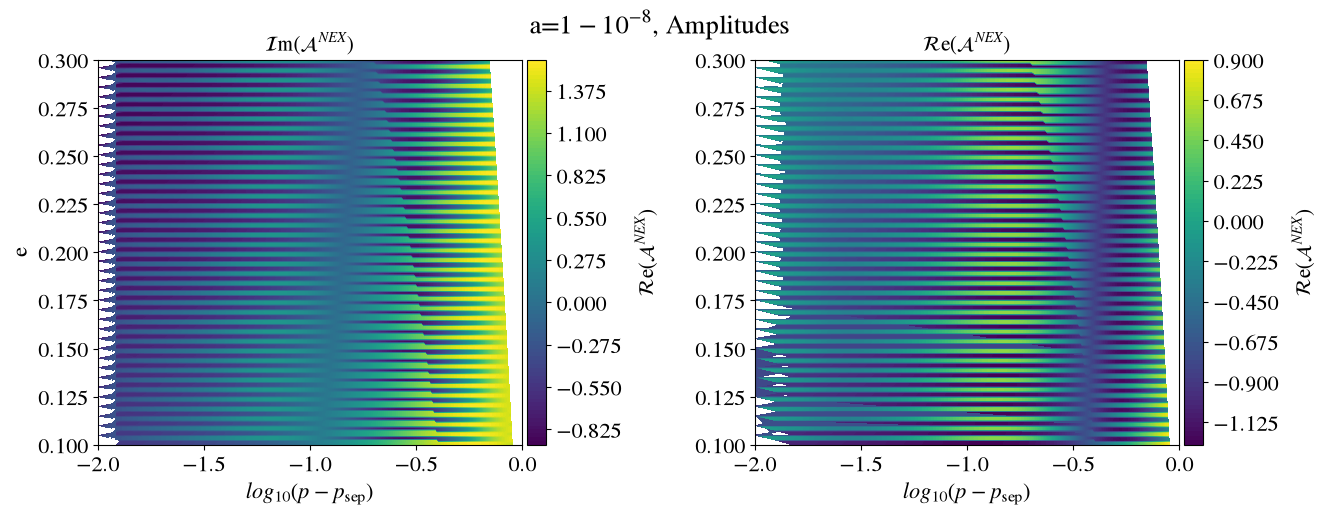

In [55]:
fig, ax = plt.subplots(1,2,figsize = (15,5))
lvs = 100

cf1 = ax[0].contourf(np.log10(np.abs(P-PSEP)), E, np.imag(Z_nex), levels=lvs, cmap="viridis")
cb1 = fig.colorbar(cf1, ax=ax[0],pad = 0.01)
cf2 = ax[1].contourf(np.log10(np.abs(P-PSEP)), E, np.real(Z_nex), levels=lvs, cmap="viridis")
cb2 = fig.colorbar(cf2, ax=ax[1] ,pad = 0.01)

cb1.set_label(r"$\mathcal{Re}(\mathcal{A}^{NEX})$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )

cb2.set_label(r"$\mathcal{Re}\left(\mathcal{A}^{NEX}\right)$", rotation =90 ,
            fontname ="STIXGeneral",  labelpad=10,fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )
ax[0].set_title(r"$\mathcal{Im}\left(\mathcal{A}^{NEX}\right)$" ,
            fontname ="STIXGeneral",fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )
ax[1].set_title(r"$\mathcal{Re}\left(\mathcal{A}^{NEX}\right)$" ,
            fontname ="STIXGeneral",fontsize=15            #,     bbox=dict(boxstyle="square", edgecolor="black", facecolor="white")
            )


ax[0].set_xlim(-2,0)
ax[1].set_xlim(-2,0)

ax[0].set_ylim(0.1,0.3)
ax[1].set_ylim(0.1,0.3)

ax[0].set_ylabel("e")

ax[1].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
ax[0].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
#ax[1].set_ylabel("e")


plt.subplots_adjust(
    wspace=0.3,  
    hspace=0.15
)


plt.suptitle(rf"a=$1-10^{{-{n}}}$, Amplitudes")
plt.show()
#fig.savefig(f"Amps_n={n}_ABS.png", dpi=300, bbox_inches="tight")